# Ridge Regression (L2)

**Flow:** correlated features → coefficient shrinkage → alpha selection.

Ridge adds an L2 penalty. Scale features inside the Pipeline so a shared alpha penalizes coefficients comparably.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.metrics import r2_score, confusion_matrix
rng=np.random.default_rng(42)

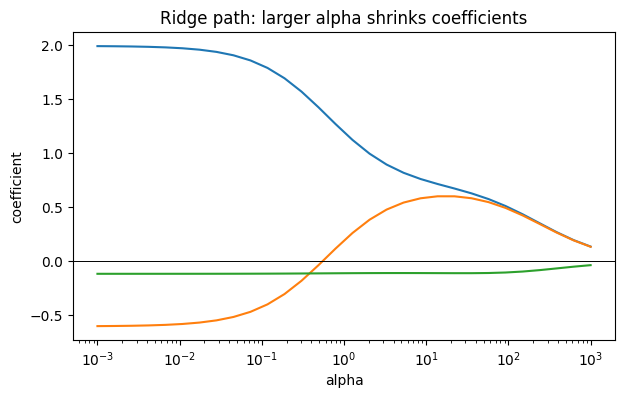

In [2]:
z=rng.normal(size=120); X=np.c_[z,z+rng.normal(0,.08,120),rng.normal(size=120)]; y=2*z+rng.normal(0,1,120); alphas=np.logspace(-3,3,30); coefs=[]
for a in alphas:
 p=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=a))]).fit(X,y); coefs.append(p.named_steps['ridge'].coef_)
plt.figure(figsize=(7,4)); plt.semilogx(alphas,coefs); plt.axhline(0,color='k',lw=.7); plt.title('Ridge path: larger alpha shrinks coefficients'); plt.xlabel('alpha'); plt.ylabel('coefficient'); plt.show()

Ridge keeps all features but reduces variance. Choose alpha using cross-validation; do not tune it on the final test set.

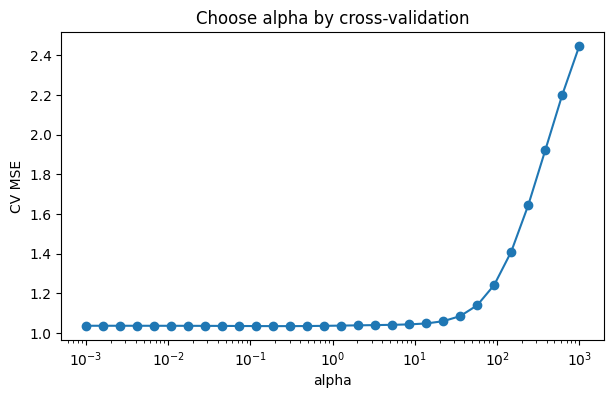

In [3]:
from sklearn.model_selection import cross_val_score
scores=[]
for a in alphas:
 p=Pipeline([('scale',StandardScaler()),('ridge',Ridge(alpha=a))]); scores.append(-cross_val_score(p,X,y,cv=5,scoring='neg_mean_squared_error').mean())
plt.figure(figsize=(7,4)); plt.semilogx(alphas,scores,'o-'); plt.title('Choose alpha by cross-validation'); plt.xlabel('alpha'); plt.ylabel('CV MSE'); plt.show()